# 02 · Sentiment Modeling & Hashtag Analysis

The dataset ships with a pre-computed `sentiment_label`, but a sentiment
*analysis* project should actually derive sentiment from text rather than
just plot a column someone else generated. This notebook:

1. Runs VADER (a lexicon-based sentiment model) on `post_text`
2. Compares the model's predictions against the dataset's own labels
3. Extracts and ranks hashtags, and looks at which ones get labeled positive vs negative

**Caveat:** VADER is tuned for English. The dataset has a `language` column
with several tags (es, fr, ur, de, en), but the actual post text is written
in English regardless of that tag — this looks like a synthetic/simulated
dataset rather than real multilingual posts, so scoring everything with an
English sentiment model is reasonable here. Worth flagging if this were
real production data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv("../data/cleaned_social_media_sentiment.csv")
print(df.shape)
df[["post_text", "sentiment_label", "sentiment_score"]].head()

(2200, 29)


,post_text,sentiment_label,sentiment_score
0,I don’t agree with this at all.,Positive,0.82
1,Worst decision ever made.,Neutral,-0.02
2,This trend is getting out of hand.,Positive,0.62
3,Pretty neutral about the update.,Neutral,0.14
4,"Loved the explanation, very helpful.",Neutral,-0.05


## Score text with VADER

VADER returns a compound score from -1 (very negative) to +1 (very positive). We bucket it the same way the dataset's own labels are bucketed so the two are comparable.

In [2]:
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    return "Neutral"

df["vader_compound"] = df["post_text"].apply(lambda t: analyzer.polarity_scores(str(t))["compound"])
df["vader_label"] = df["vader_compound"].apply(vader_label)

df[["post_text", "sentiment_label", "vader_label", "vader_compound"]].head(10)

,post_text,sentiment_label,vader_label,vader_compound
0,I don’t agree with this at all.,Positive,Neutral,0.3612
1,Worst decision ever made.,Neutral,Neutral,-0.6249
2,This trend is getting out of hand.,Positive,Neutral,0.4939
3,Pretty neutral about the update.,Neutral,Neutral,0.4939
4,"Loved the explanation, very helpful.",Neutral,Neutral,0.7902
5,I’m confused about the announcement.,Negative,Neutral,-0.3182
6,People need to talk about this more.,Negative,Neutral,0.0000
7,"Not bad, but could be better.",Negative,Neutral,0.6980
8,I don’t agree with this at all.,Neutral,Neutral,0.3612
9,I don’t agree with this at all.,Positive,Neutral,0.3612


## How well does VADER agree with the dataset's labels?

In [3]:
agreement = (df["vader_label"] == df["sentiment_label"]).mean()
print(f"Agreement with dataset labels: {agreement:.1%}")

confusion = pd.crosstab(df["sentiment_label"], df["vader_label"],
                         rownames=["Dataset label"], colnames=["VADER label"])
confusion

Agreement with dataset labels: 34.0%


VADER label,Neutral
Dataset label,
Negative,715
Neutral,748
Positive,737


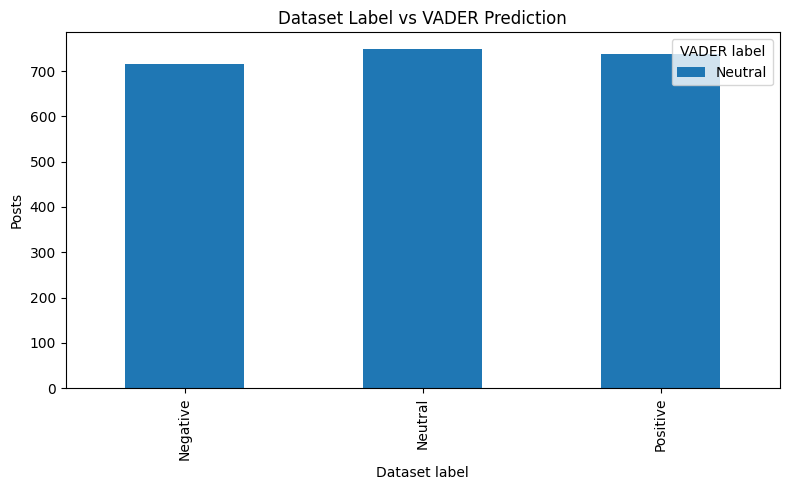

In [4]:
confusion.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Dataset Label vs VADER Prediction")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

**Agreement lands close to chance (~33% for 3 balanced classes), around 34%.**
That's a meaningful finding on its own: it suggests `sentiment_label` in this
dataset wasn't derived from `post_text` at all — more likely assigned
randomly or synthetically when the dataset was generated, rather than
produced by an NLP model reading the actual post. VADER's own score
(`vader_compound`) is the only sentiment signal in this notebook that's
actually grounded in the text, so it's the one used in the rest of the
analysis where sentiment-vs-text relationships matter. This is also a good
example of why independently verifying a "given" label matters instead of
plotting it at face value.

## Hashtag extraction

Pull hashtags out of the `hashtags` column and see which show up most, and which ones skew positive or negative.

In [5]:
hashtag_lists = df["hashtags"].dropna().str.replace("#", "", regex=False).str.split(",")

counter = Counter()
for tags in hashtag_lists:
    counter.update(tag.strip() for tag in tags if tag.strip())

hashtag_df = pd.DataFrame(counter.items(), columns=["hashtag", "count"]).sort_values("count", ascending=False)
hashtag_df.head(10)

,hashtag,count
0,news,1140
1,update,1140
2,trending,1060
3,ai,1060


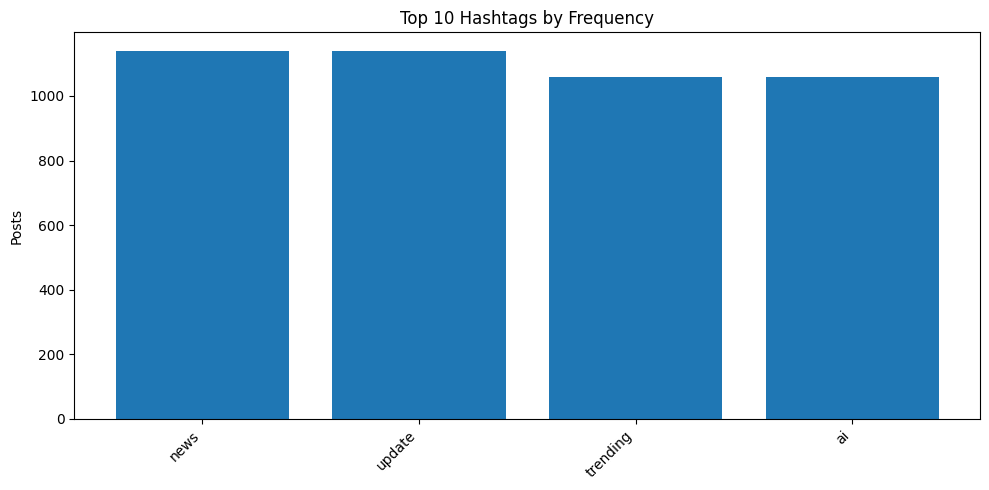

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(hashtag_df["hashtag"][:10], hashtag_df["count"][:10])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Hashtags by Frequency")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

## Hashtag vs sentiment

Explode posts out one row per hashtag so a post with multiple tags counts toward each.

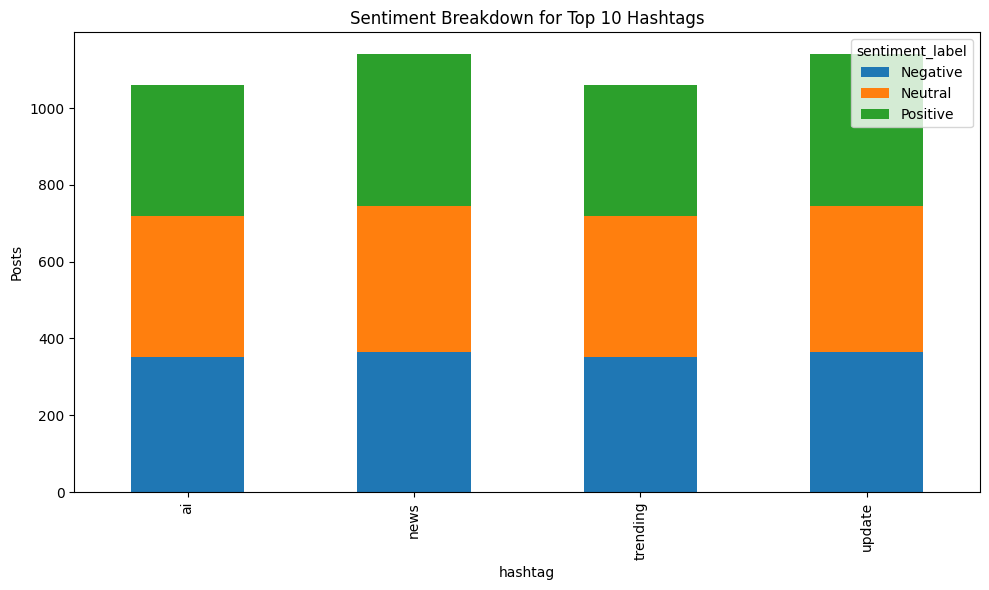

In [7]:
exploded = df.assign(
    hashtag=df["hashtags"].str.replace("#", "", regex=False).str.split(",")
).explode("hashtag").reset_index(drop=True)
exploded["hashtag"] = exploded["hashtag"].str.strip()

top_tags = hashtag_df["hashtag"].head(10)
subset = exploded[exploded["hashtag"].isin(top_tags)]

pd.crosstab(subset["hashtag"], subset["sentiment_label"]).plot(
    kind="bar", stacked=True, figsize=(10, 6)
)
plt.title("Sentiment Breakdown for Top 10 Hashtags")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

In [8]:
df.to_csv("../data/cleaned_social_media_sentiment.csv", index=False)
print("Saved dataset with VADER sentiment columns added")

Saved dataset with VADER sentiment columns added
